# 1.2 Raw Data Preprocessing

Clean and validate the raw data, then save the preprocessed version.

**Steps:**
1. Load raw data
2. Handle missing values
3. Fix data types
4. Detect and handle outliers
5. Create house_age feature
6. Validate data integrity
7. Save preprocessed data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1.2.1 Load Raw Data

In [2]:
RAW_DATA_PATH = 'data/raw/house_data.csv'
PROCESSED_DIR = 'data/processed'

os.makedirs(PROCESSED_DIR, exist_ok=True)

df = pd.read_csv(RAW_DATA_PATH)
print(f'Loaded {df.shape[0]} rows and {df.shape[1]} columns')
df.head()

Loaded 84 rows and 7 columns


,price,sqft,bedrooms,bathrooms,location,year_built,condition
0,495000,1527,2,1.5,Suburb,1956,Good
1,752000,2526,3,2.5,Downtown,1998,Excellent
2,319000,1622,2,1.5,Rural,1975,Fair
3,1210000,3102,4,3.0,Waterfront,2005,Excellent
4,462000,1835,2,2.0,Urban,1982,Good


## 1.2.2 Handle Missing Values

In [3]:
initial_rows = len(df)
df = df.dropna(subset=['price'])
print(f'Dropped {initial_rows - len(df)} rows with missing price.')

numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'Filled {col} missing values with median: {median_val}')

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'Filled {col} missing values with mode: {mode_val}')

print(f'\nRemaining missing values: {df.isnull().sum().sum()}')

Dropped 0 rows with missing price.

Remaining missing values: 0


## 1.2.3 Fix Data Types

In [4]:
df['price'] = df['price'].astype(float)
df['sqft'] = df['sqft'].astype(int)
df['bedrooms'] = df['bedrooms'].astype(int)
df['bathrooms'] = df['bathrooms'].astype(float)
df['year_built'] = df['year_built'].astype(int)

print('Updated dtypes:')
print(df.dtypes)

Updated dtypes:
price         float64
sqft            int64
bedrooms        int64
bathrooms     float64
location       object
year_built      int64
condition      object
dtype: object


## 1.2.4 Detect and Handle Outliers

price: 7 outliers detected (8.3%)
sqft: 0 outliers detected (0.0%)


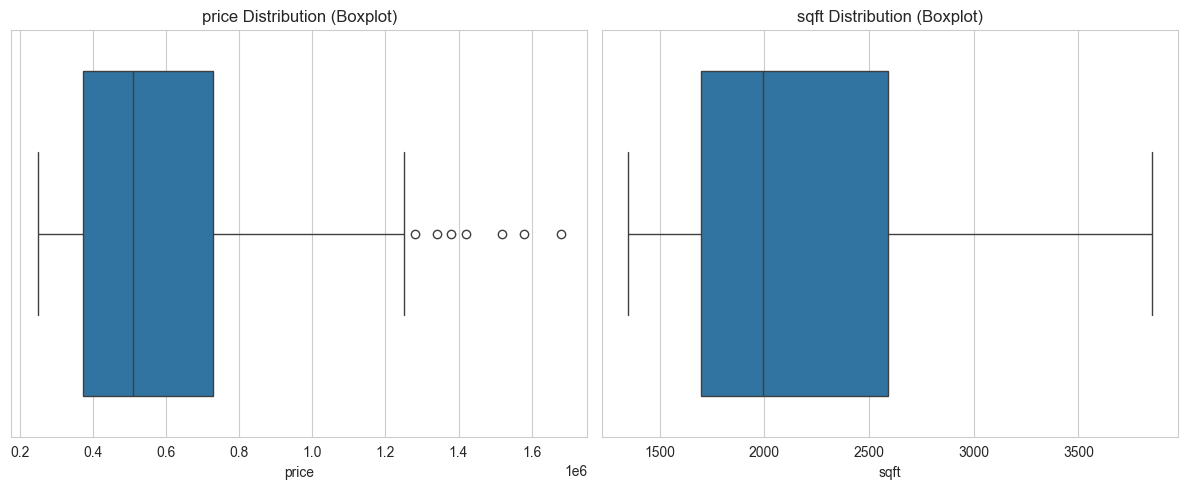

In [5]:
def detect_outliers_iqr(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return (series < lower) | (series > upper)

outlier_cols = ['price', 'sqft']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(outlier_cols):
    outlier_mask = detect_outliers_iqr(df[col])
    n_outliers = outlier_mask.sum()
    print(f'{col}: {n_outliers} outliers detected ({n_outliers/len(df)*100:.1f}%)')
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'{col} Distribution (Boxplot)')

plt.tight_layout()
plt.show()

In [6]:
def cap_outliers(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return series.clip(lower, upper)

for col in outlier_cols:
    before = df[col].describe()
    df[col] = cap_outliers(df[col])
    after = df[col].describe()
    print(f'{col}: capped outliers. Range changed from [{before["min"]:.0f}, {before["max"]:.0f}] to [{after["min"]:.0f}, {after["max"]:.0f}]')

price: capped outliers. Range changed from [249000, 1680000] to [249000, 1261750]
sqft: capped outliers. Range changed from [1350, 3850] to [1350, 3850]


## 1.2.5 Feature: Age of House

In [7]:
CURRENT_YEAR = 2026
df['house_age'] = CURRENT_YEAR - df['year_built']
print('house_age statistics:')
print(df['house_age'].describe())

house_age statistics:
count    84.000000
mean     43.952381
std      19.501563
min       7.000000
25%      30.500000
50%      43.500000
75%      61.000000
max      79.000000
Name: house_age, dtype: float64


## 1.2.6 Data Validation

In [8]:
assert df['price'].min() > 0, 'Price has non-positive values!'
assert df['sqft'].min() > 0, 'Sqft has non-positive values!'
assert df['bedrooms'].min() >= 0, 'Bedrooms has negative values!'
assert df['bathrooms'].min() >= 0, 'Bathrooms has negative values!'
assert df['year_built'].min() >= 1900, 'year_built has suspicious values!'
assert df['year_built'].max() <= CURRENT_YEAR, 'year_built has future dates!'
assert df['location'].isin(['Suburb', 'Downtown', 'Rural', 'Waterfront', 'Urban', 'Mountain']).all(), 'Unexpected location values!'
assert df['condition'].isin(['Poor', 'Fair', 'Good', 'Excellent']).all(), 'Unexpected condition values!'

print('All data validation checks passed.')

All data validation checks passed.


## 1.2.7 Save Preprocessed Data

In [9]:
output_path = os.path.join(PROCESSED_DIR, 'house_data_preprocessed.csv')
df.to_csv(output_path, index=False)
print(f'Saved preprocessed data to {output_path}')
print(f'Shape: {df.shape}')
df.head()

Saved preprocessed data to data/processed\house_data_preprocessed.csv
Shape: (84, 8)


,price,sqft,bedrooms,bathrooms,location,year_built,condition,house_age
0,495000.0,1527,2,1.5,Suburb,1956,Good,70
1,752000.0,2526,3,2.5,Downtown,1998,Excellent,28
2,319000.0,1622,2,1.5,Rural,1975,Fair,51
3,1210000.0,3102,4,3.0,Waterfront,2005,Excellent,21
4,462000.0,1835,2,2.0,Urban,1982,Good,44
